In [2]:
import os, sys

# Project paths
if os.path.basename(os.getcwd()) == "notebook":
    _PROJECT_ROOT = os.path.dirname(os.getcwd())
elif os.path.isdir(os.path.join(os.getcwd(), "src")):
    _PROJECT_ROOT = os.getcwd()
else:
    raise FileNotFoundError(
        "Cannot find project root. Run from the project root or notebook/ directory."
    )

DATA_DIR = os.path.join(_PROJECT_ROOT, "data")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.stats import chi2_contingency, pointbiserialr, mannwhitneyu, pearsonr

import pickle

In [3]:
data_path = os.path.join(DATA_DIR, "processed_data.csv")
df = pd.read_csv(data_path)

C:\Users\18327\AppData\Local\Temp\ipykernel_26532\2604124036.py:2: DtypeWarning: Columns (71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


In [4]:
df.head()

,_MICHD,_TOTINDA,_AGEG5YR,_RACE,MARITAL,VETERAN3,PREGNANT,_EDUCAG,_INCOMG1,SDHBILLS,...,ACEDIVRC,ACEPUNCH,ACEHURT1,ACEADSAF,CIMEMLO1,CDSOCIA1,_BMI5,HTIN4,MSCODE,_ismale
0,0.0,1.0,12.0,"White only, non-Hispanic",Widowed,No,Unknown,Grad High,Unknown,No,...,Unknown,Unknown,Unknown,Unknown,No,Unknown,2249.0,64.0,Center City MSA,0
1,1.0,1.0,13.0,"White only, non-Hispanic",Married,Yes,Unknown,Grad College,"$200,000 or more",No,...,Unknown,Unknown,Unknown,Unknown,No,Unknown,2583.0,70.0,Center City MSA,1
2,0.0,1.0,8.0,"White only, non-Hispanic",Unmarried couple,Yes,Unknown,Attend College,Unknown,No,...,Unknown,Unknown,Unknown,Unknown,No,Unknown,2253.0,78.0,Not MSA,1
3,0.0,1.0,13.0,"White only, non-Hispanic",Married,No,Unknown,Grad College,"$35,000 to < $50,000",No,...,Unknown,Unknown,Unknown,Unknown,No,Unknown,2509.0,68.0,Not MSA,1
4,0.0,0.0,6.0,"White only, non-Hispanic",Never married,No,Unknown,Attend College,"$15,000 to < $25,000",No,...,Unknown,Unknown,Unknown,Unknown,No,Unknown,1977.0,68.0,Center City MSA,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452464 entries, 0 to 452463
Data columns (total 73 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   _MICHD    452464 non-null  float64
 1   _TOTINDA  451270 non-null  float64
 2   _AGEG5YR  452464 non-null  float64
 3   _RACE     452464 non-null  object 
 4   MARITAL   452464 non-null  object 
 5   VETERAN3  452464 non-null  object 
 6   PREGNANT  452464 non-null  object 
 7   _EDUCAG   452464 non-null  object 
 8   _INCOMG1  452464 non-null  object 
 9   SDHBILLS  452464 non-null  object 
 10  SDHTRNSP  452464 non-null  object 
 11  HOWSAFE1  452464 non-null  object 
 12  PRIMINS2  452464 non-null  object 
 13  _RFHLTH   452464 non-null  object 
 14  PHYSHLTH  176477 non-null  float64
 15  MENTHLTH  177534 non-null  float64
 16  POORHLTH  124272 non-null  float64
 17  CVDSTRK3  452464 non-null  object 
 18  _RFBMI5   452464 non-null  object 
 19  DIABETE4  452464 non-null  object 
 20  DIAB

In [6]:
df.describe()

,_MICHD,_TOTINDA,_AGEG5YR,PHYSHLTH,MENTHLTH,POORHLTH,LCSFIRST,LCSNUMCG,_LCSYSMK,_LCSYQTS,AVEDRNK4,_DRNKWK3,MAXDRNKS,SSBSUGR2,_BMI5,HTIN4,_ismale
count,452464.000000,451270.000000,452464.000000,176477.000000,177534.000000,124272.000000,153566.000000,150795.000000,149871.000000,119217.000000,206225.000000,406603.000000,202508.000000,60424.000000,410281.000000,421325.000000,452464.000000
mean,0.093572,0.768746,7.764786,11.432430,11.013862,11.286991,17.792168,15.047581,24.402473,21.869280,2.257554,279.541186,3.383229,0.772607,2855.161969,67.050600,0.474712
std,0.291233,0.421635,3.735420,10.920214,10.063311,10.273144,5.098642,12.402441,16.445062,17.479259,2.410996,894.006497,3.499086,3.497152,657.777866,4.204138,0.499361
min,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,-30.000000,0.000000,0.000000,0.000000,0.033333,1200.000000,36.000000,0.000000
25%,0.000000,1.000000,5.000000,2.000000,3.000000,3.000000,15.000000,7.000000,10.000000,6.000000,1.000000,0.000000,1.000000,0.066667,2414.000000,64.000000,0.000000
50%,0.000000,1.000000,8.000000,6.000000,7.000000,7.000000,17.000000,10.000000,22.000000,19.000000,2.000000,23.000000,2.000000,0.166667,2744.000000,67.000000,0.000000
75%,0.000000,1.000000,11.000000,20.000000,15.000000,20.000000,19.000000,20.000000,37.000000,36.000000,3.000000,233.000000,4.000000,1.000000,3175.000000,70.000000,1.000000
max,1.000000,1.000000,14.000000,30.000000,30.000000,30.000000,99.000000,490.000000,90.000000,83.000000,76.000000,53200.000000,76.000000,99.000000,9984.000000,95.000000,1.000000


In [7]:
# Parameters
TARGET = '_MICHD'
CHUNK  = 9
P_THRESHOLD = 0.05
CV_THRESHOLD = 0.09 #binary
CORR_THRESHOLD = 0.1 #continuous

In [8]:
# Extract Multi-class Categorical Columns
# This catches string/object types AND numeric columns with low unique values
categorical_cols = [
    c for c in df.columns 
    if c != TARGET 
    and (df[c].dtype == 'object' or df[c].dtype.name == 'category' or df[c].nunique() < 10)
]

# Extract True Continuous Columns
# Only counts numeric columns with a high number of unique values
continuous_cols = [
    c for c in df.select_dtypes("number").columns 
    if c != TARGET 
    and c not in categorical_cols
]

In [9]:
print(f"Number of all columns: {len(df.columns)}")
print(f"Number of categorical feature columns: {len(categorical_cols)}")
print(f"Number of continuous feature columns: {len(continuous_cols)}")

Number of all columns: 73
Number of categorical feature columns: 58
Number of continuous feature columns: 14


In [10]:
# Helper Functions
def cramers_v(x, y):
    ct   = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n    = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

def plot_chunks(cols, plot_fn, suptitle_fmt, cols_per_row=3):
    chunks = [cols[i:i+CHUNK] for i in range(0, len(cols), CHUNK)]
    for batch, chunk in enumerate(chunks, 1):
        n_cols = min(cols_per_row, len(chunk))
        n_rows = (len(chunk) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols,
                                 figsize=(n_cols * 4.5, n_rows * 3.5))
        axes = np.array(axes).flatten()
        for j, col in enumerate(chunk):
            plot_fn(col, j, axes[j])
        for k in range(len(chunk), len(axes)):
            axes[k].set_visible(False)
        fig.suptitle(suptitle_fmt.format(batch, len(chunks)),
                     y=1.01, fontsize=12)
        plt.tight_layout(); plt.show()

### Univariate Significance Testing & Effect Size Estimation on Categorical Variables vs\. \_MICHD

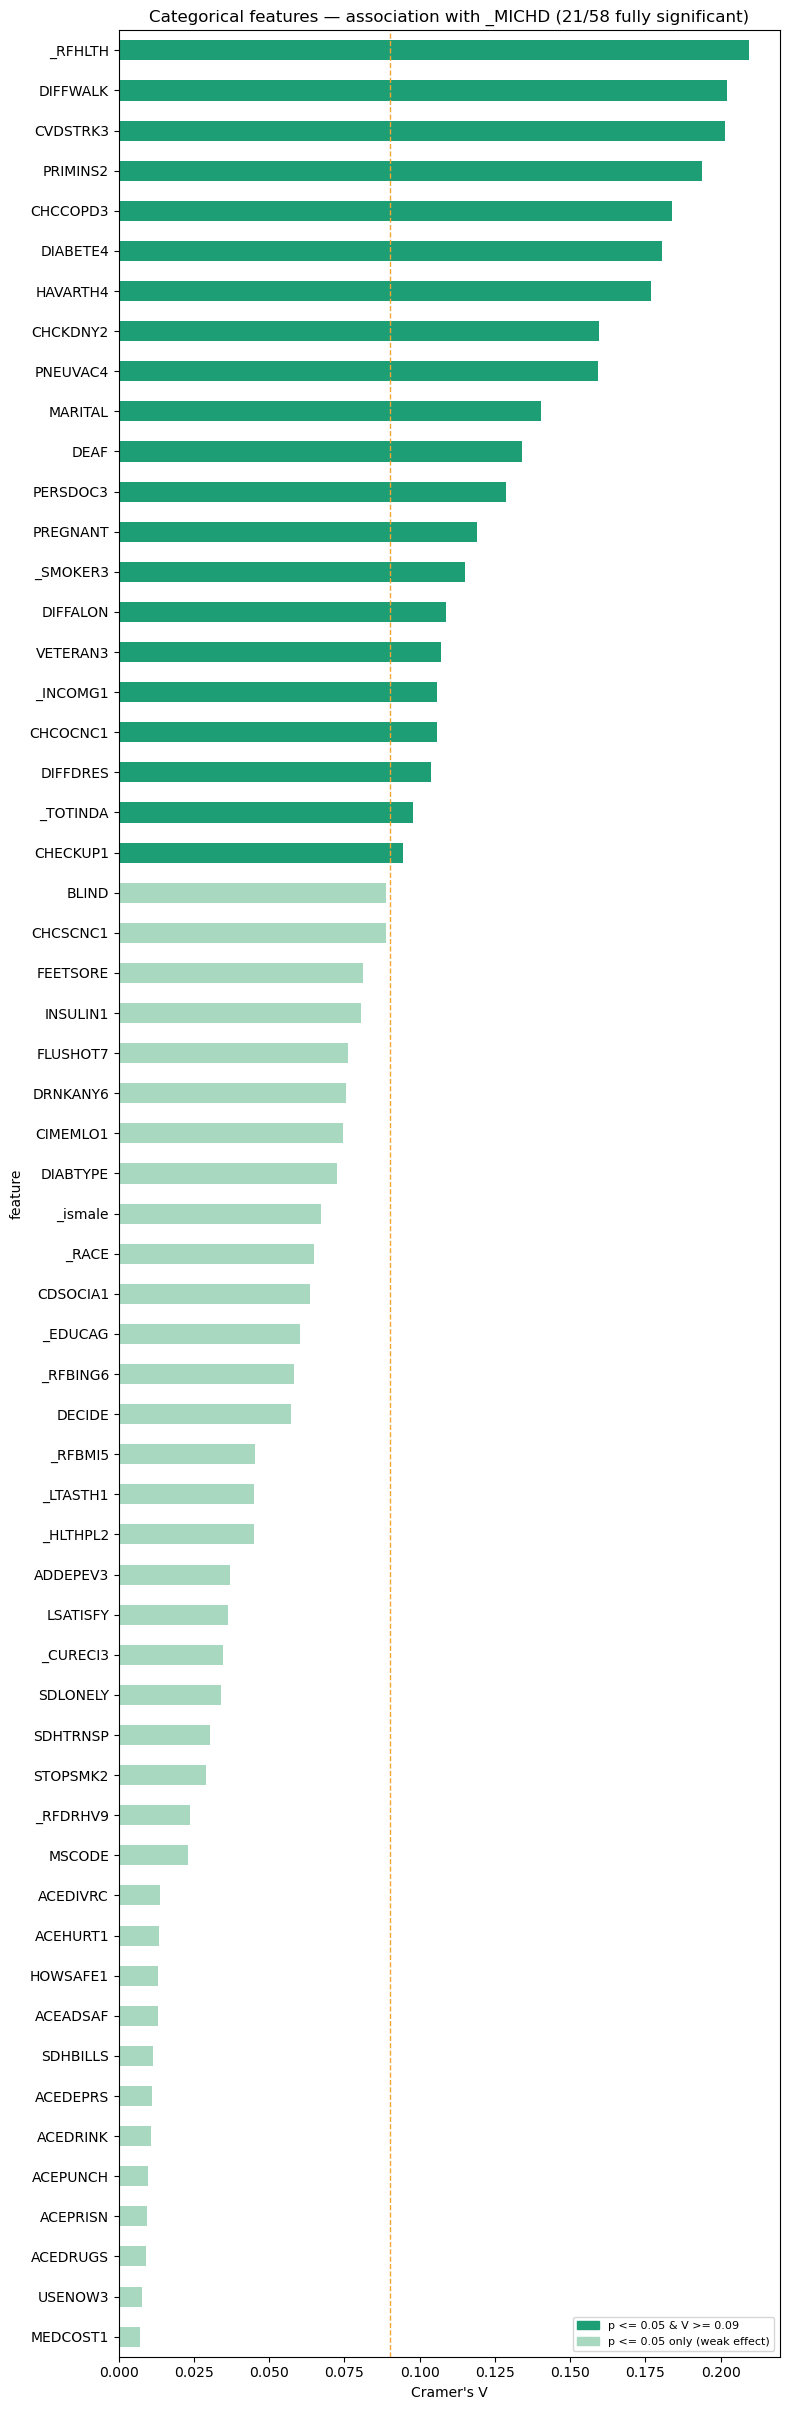

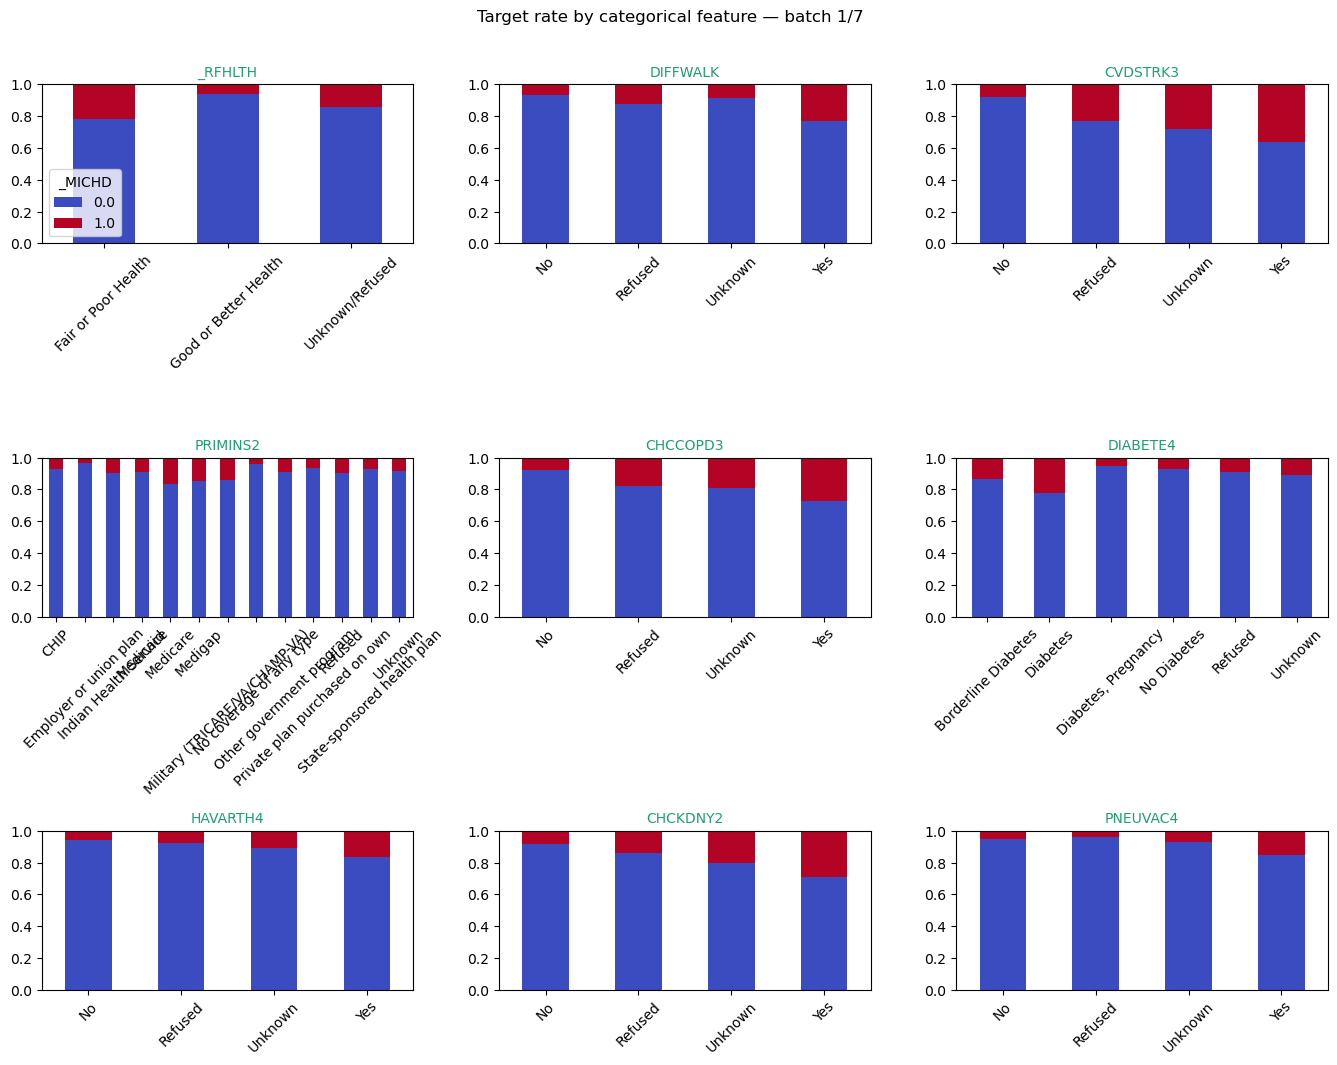

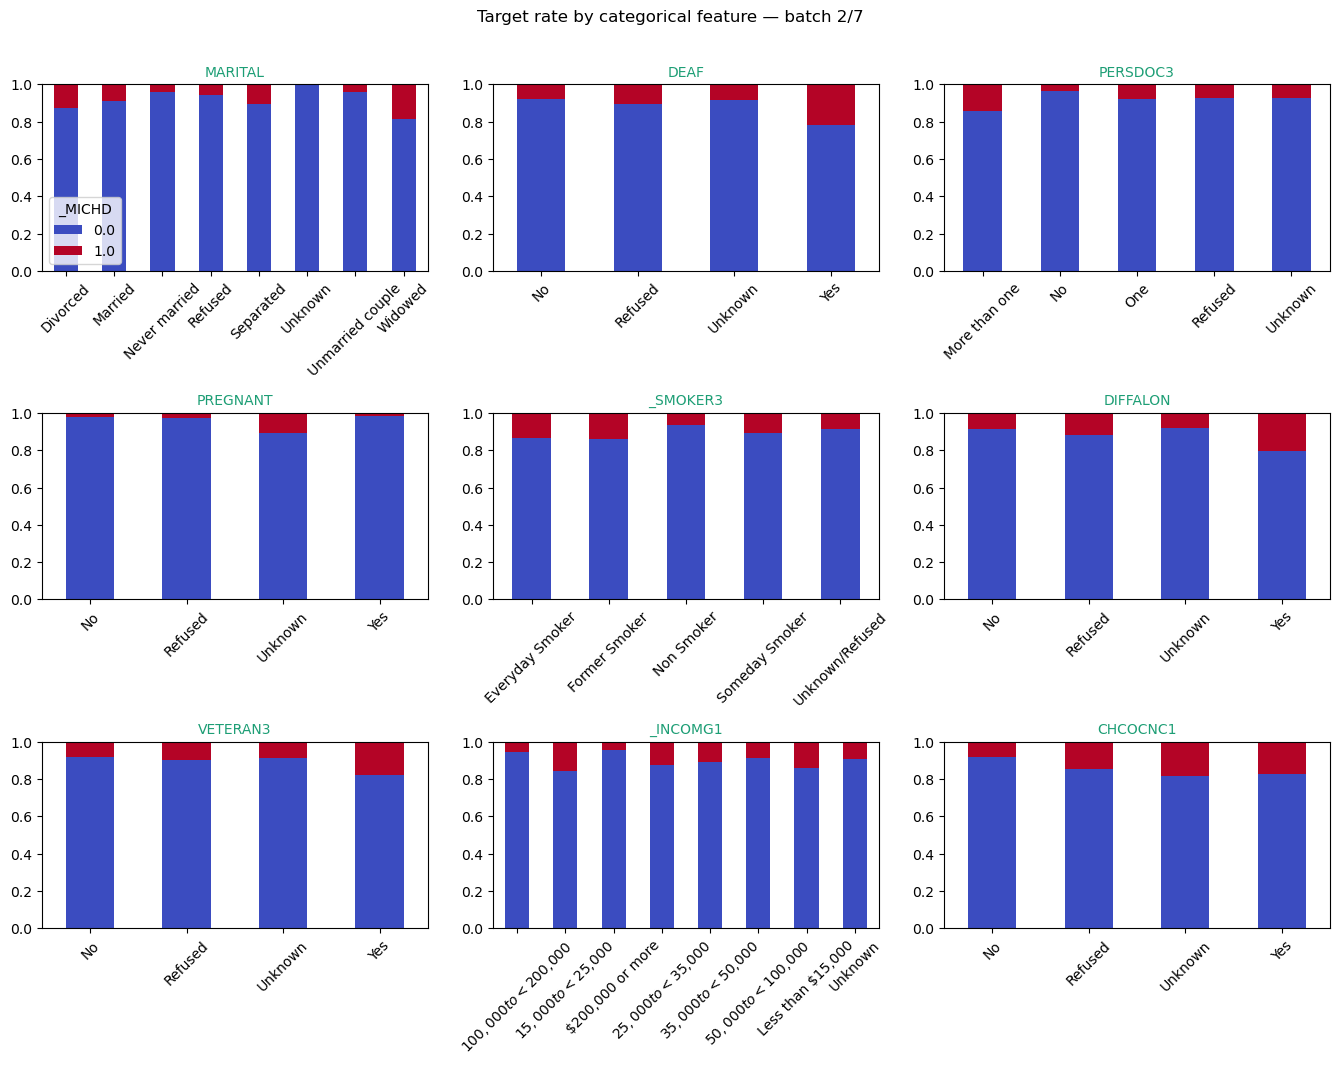

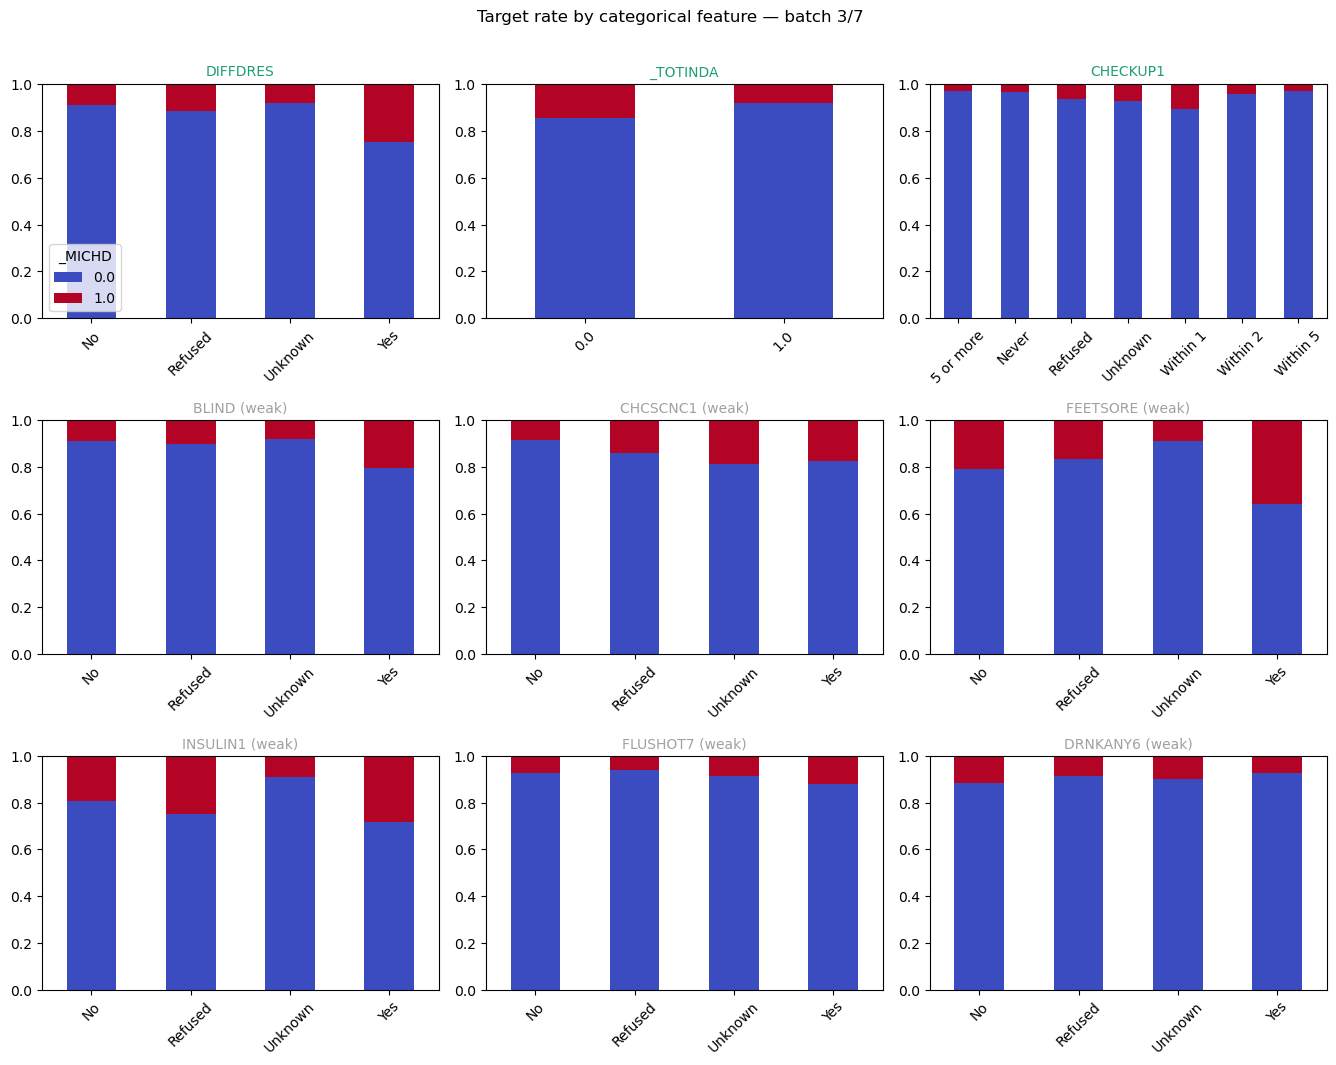

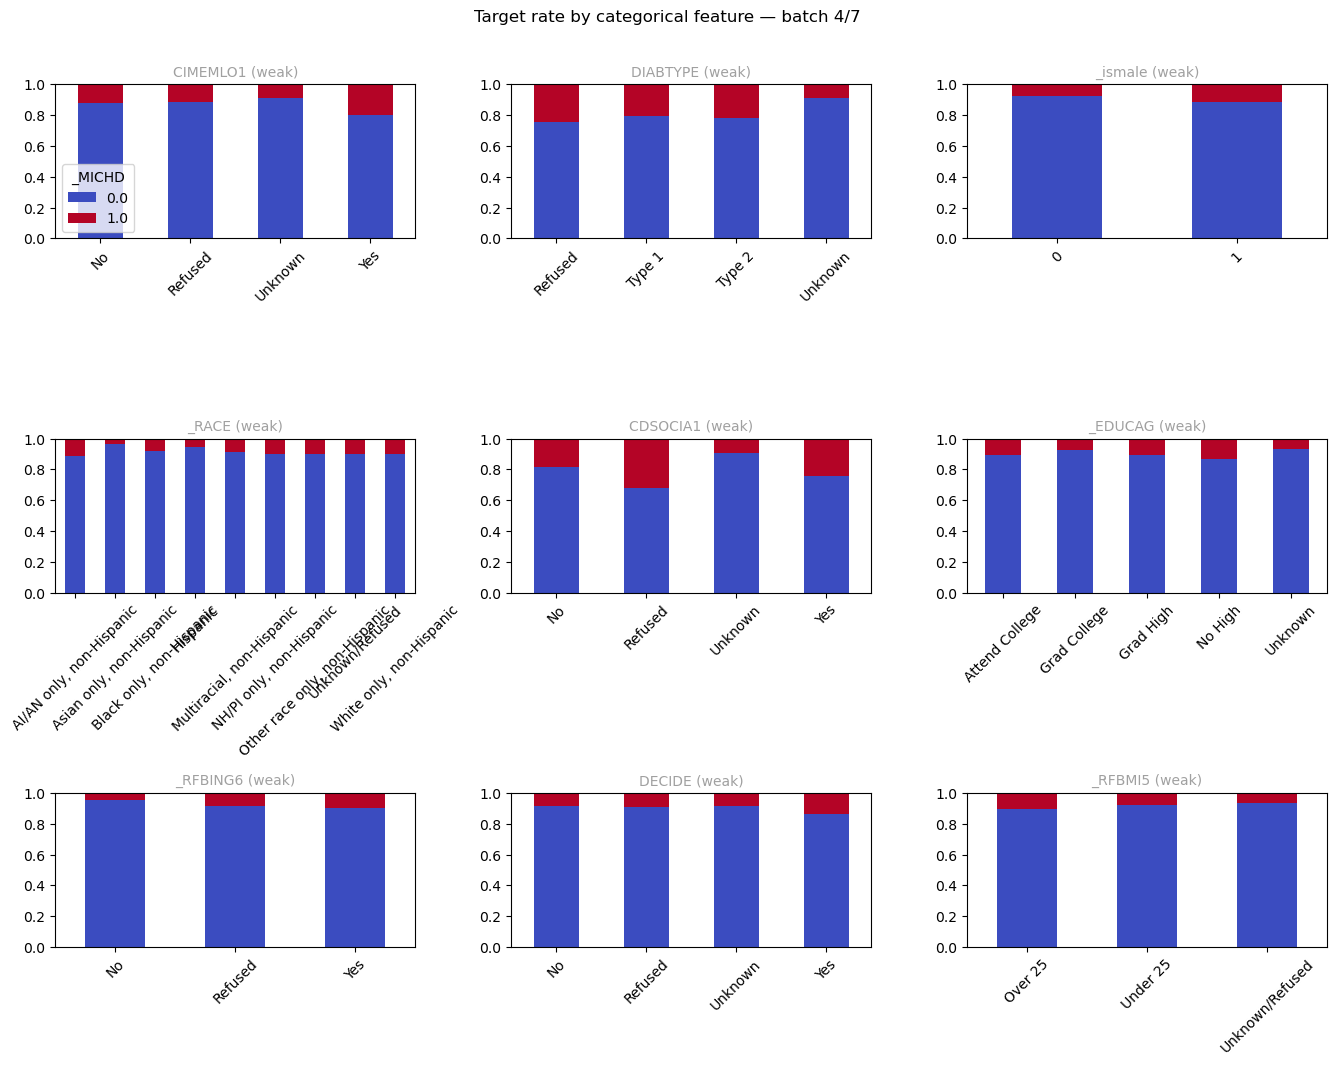

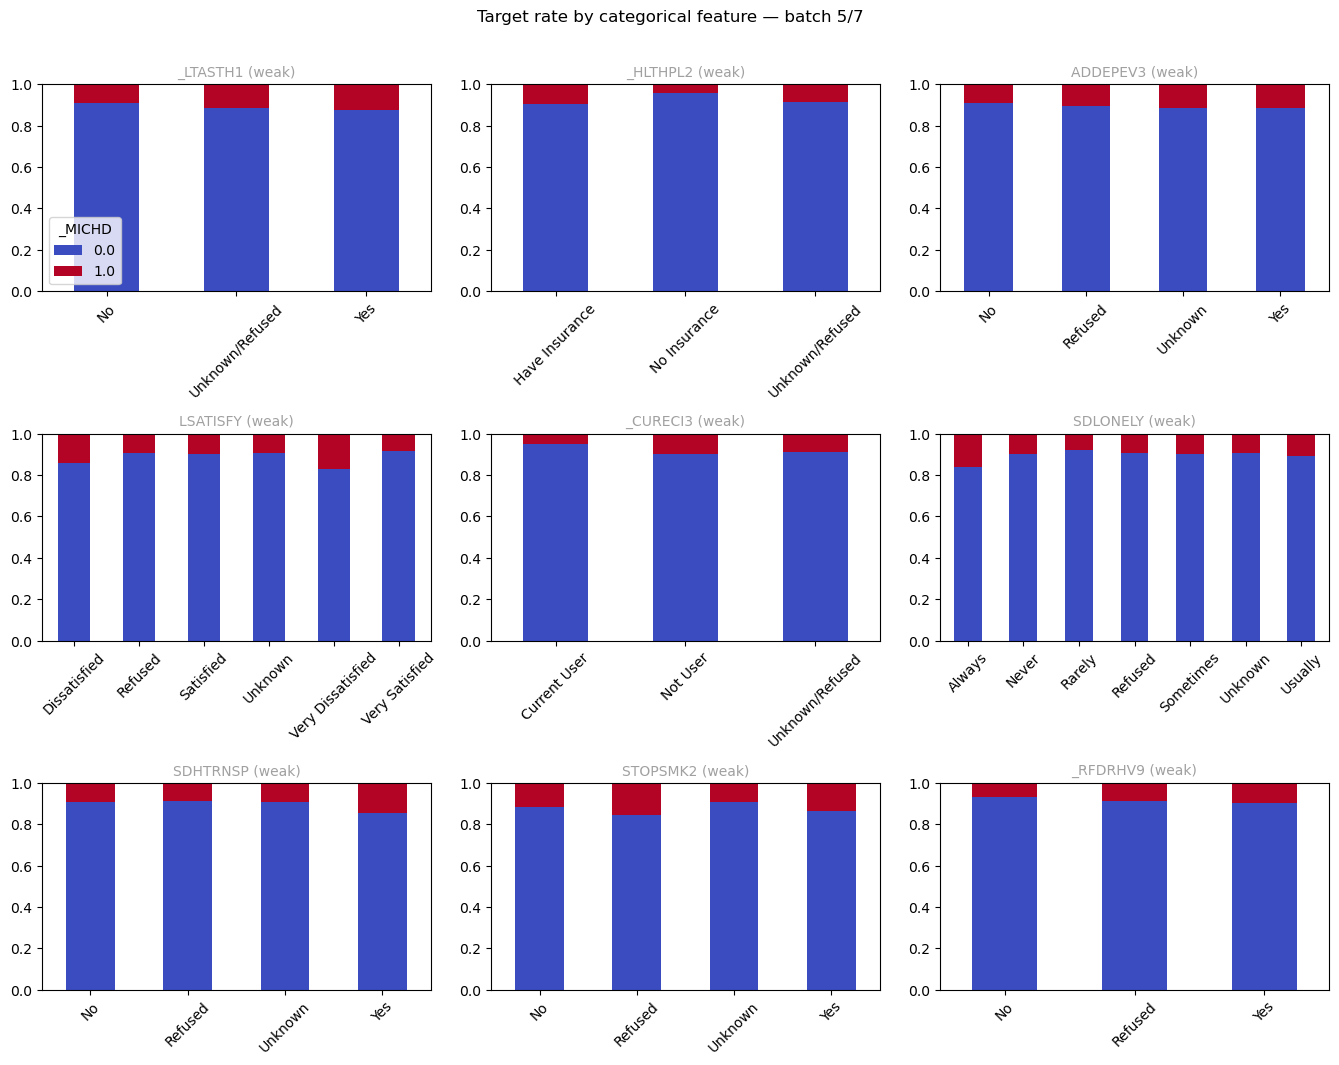

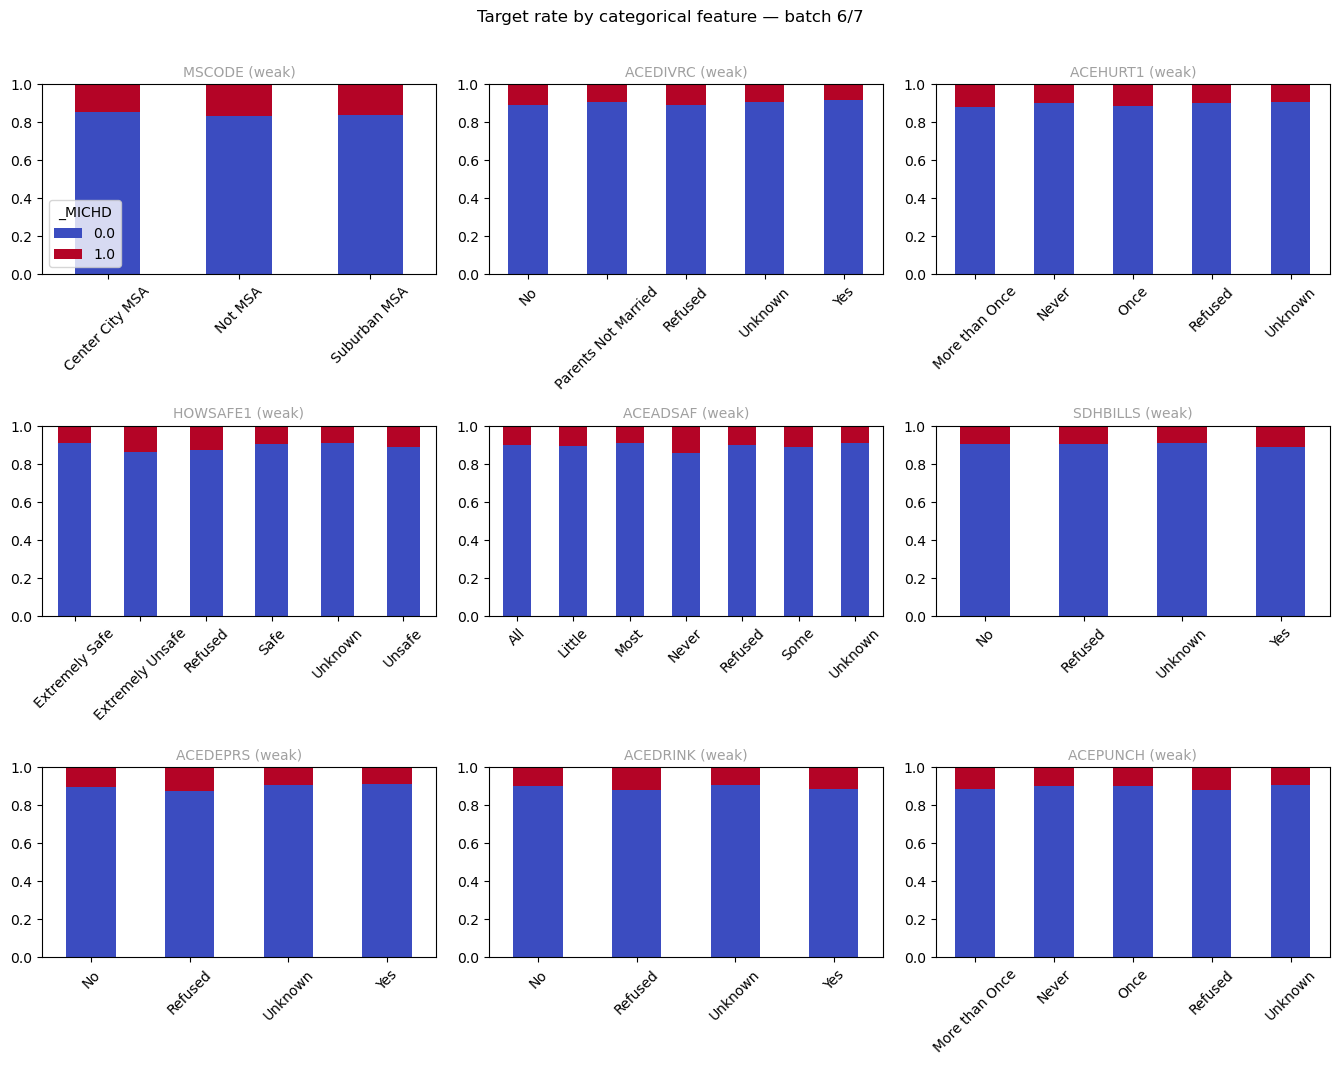

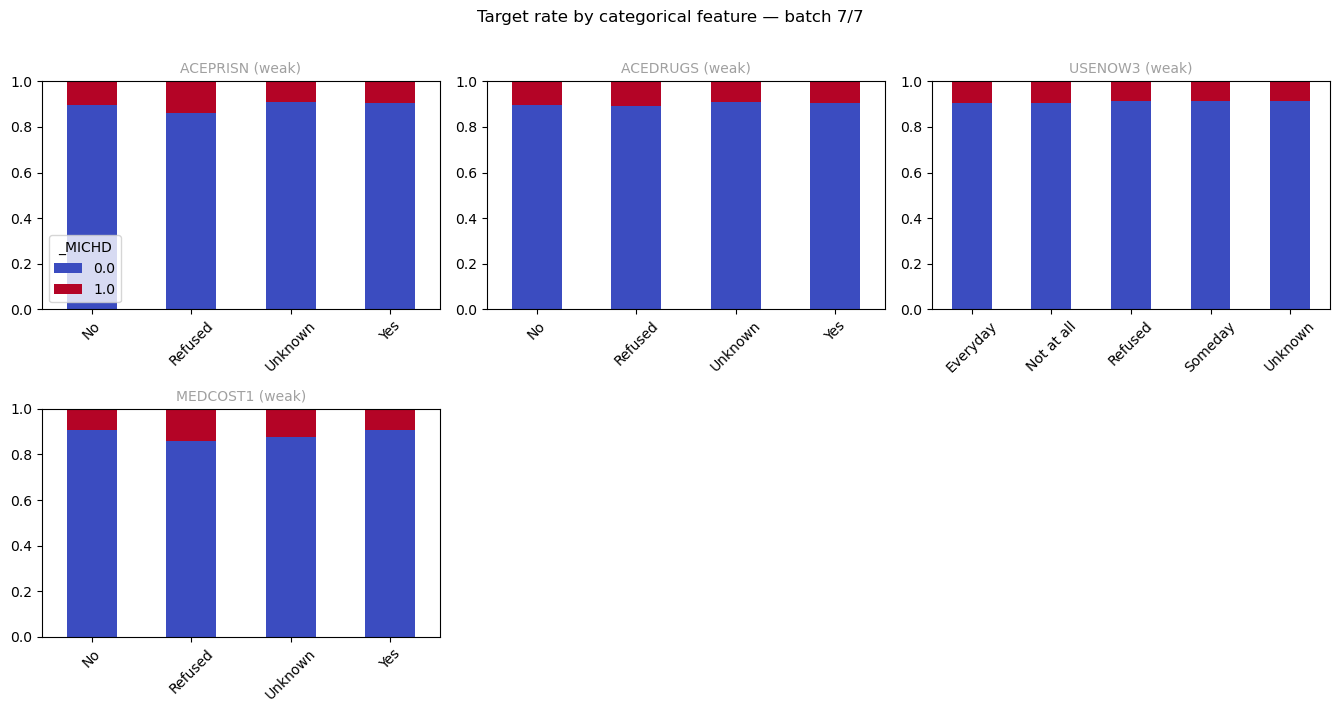

,feature,cramers_v,p_value,sig_p,sig_cv,sig_cat
11,_RFHLTH,0.209266,0.000000e+00,True,True,both
37,DIFFWALK,0.202196,0.000000e+00,True,True,both
12,CVDSTRK3,0.201371,0.000000e+00,True,True,both
10,PRIMINS2,0.193921,0.000000e+00,True,True,both
25,CHCCOPD3,0.183726,0.000000e+00,True,True,both
14,DIABETE4,0.180588,0.000000e+00,True,True,both
27,HAVARTH4,0.176755,0.000000e+00,True,True,both
26,CHCKDNY2,0.159443,0.000000e+00,True,True,both
45,PNEUVAC4,0.159317,0.000000e+00,True,True,both
2,MARITAL,0.140185,0.000000e+00,True,True,both


In [ ]:
# Multi-class Categorical Features Analysis
cat_results = []

# Loop through multi-class categorical columns
for col in categorical_cols:
    clean = df[[col, TARGET]].dropna()
    ct = pd.crosstab(clean[col], clean[TARGET])
    
    # chi2_contingency and cramers_v natively support multi-class categories
    chi2, pval, _, _ = chi2_contingency(ct)
    cv = cramers_v(clean[col], clean[TARGET])
    
    cat_results.append({"feature": col, "cramers_v": cv, "p_value": pval})

cat_df = pd.DataFrame(cat_results).sort_values("cramers_v", ascending=False)
cat_df["sig_p"] = cat_df["p_value"] <= P_THRESHOLD
cat_df["sig_cv"] = cat_df["cramers_v"] >= CV_THRESHOLD

# 4-way classification
def _sig_category(row):
    if row["sig_p"] and row["sig_cv"]: return "both"
    if row["sig_p"]: return "p_only"
    if row["sig_cv"]: return "cv_only"
    return "neither"

cat_df["sig_cat"] = cat_df.apply(_sig_category, axis=1)
sig_cat_feats = cat_df[cat_df["sig_cat"] == "both"]["feature"].tolist()
all_cat_feats = cat_df["feature"].tolist()

# Color config
CAT_COLOR = {
    "both": "#1D9E75",    # green: strong signal
    "p_only": "#A8D8C0",  # mint: significant but weak effect
    "cv_only": "#F4A736", # amber: notable effect, unreliable p
    "neither": "#B0B0B0", # grey: nothing
}
CAT_LABEL = {
    "both": f"p <= {P_THRESHOLD} & V >= {CV_THRESHOLD}",
    "p_only": f"p <= {P_THRESHOLD} only (weak effect)",
    "cv_only": f"V >= {CV_THRESHOLD} only (unreliable p)",
    "neither": "Not significant",
}

# Ranking chart
feat_idx = cat_df.set_index("feature")
plot_df = feat_idx.loc[all_cat_feats, "cramers_v"].sort_values()
colors = [CAT_COLOR[feat_idx.loc[f, "sig_cat"]] for f in plot_df.index]

fig, ax = plt.subplots(figsize=(8, max(3, len(all_cat_feats) * 0.4 + 1)))
plot_df.plot(kind="barh", ax=ax, color=colors)
ax.axvline(CV_THRESHOLD, color="#F4A736", linewidth=1, linestyle="--", label=f"V = {CV_THRESHOLD}")
ax.axvline(0, color="black", linewidth=0.6)
ax.set_xlabel("Cramer's V")
ax.set_title(f"Categorical features - association with {TARGET} "
             f"({len(sig_cat_feats)}/{len(all_cat_feats)} fully significant)")

present_cats = cat_df["sig_cat"].unique()
legend_patches = [Patch(color=CAT_COLOR[c], label=CAT_LABEL[c]) for c in ["both", "p_only", "cv_only", "neither"] if c in present_cats]
ax.legend(handles=legend_patches, loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

# Stacked bar grids
CAT_SUFFIX = {"both": "", "p_only": " (weak)", "cv_only": " (p?)", "neither": " (ns)"}

def cat_plot_fn(col, j, ax):
    ct = pd.crosstab(df[col], df[TARGET], normalize="index")
    ct.plot(kind="bar", stacked=True, ax=ax, colormap="coolwarm", legend=(j == 0), rot=45) 
    
    cat = feat_idx.loc[col, "sig_cat"]
    color = CAT_COLOR[cat] if cat == "both" else "#A0A0A0"
    ax.set_title(f"{col}{CAT_SUFFIX[cat]}", fontsize=10, color=color)
    ax.set_ylim(0, 1)
    ax.set_xlabel("")

# Call plot_chunks using the new categorical features list
plot_chunks(all_cat_feats, cat_plot_fn, "Target rate by categorical feature - batch {}/{}")

cat_df

### Univariate Significance Testing & Effect Size Estimation on Continuous Variables vs\. \_MICHD

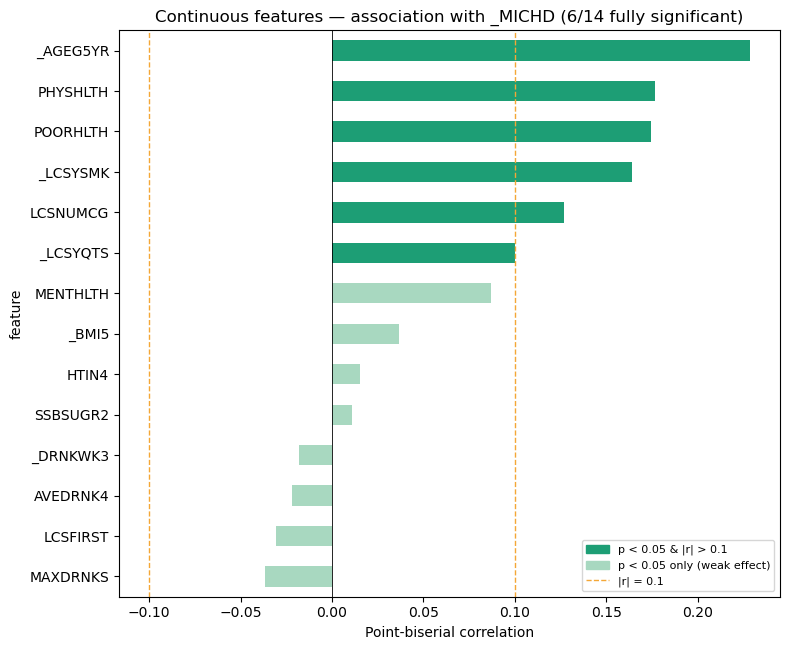

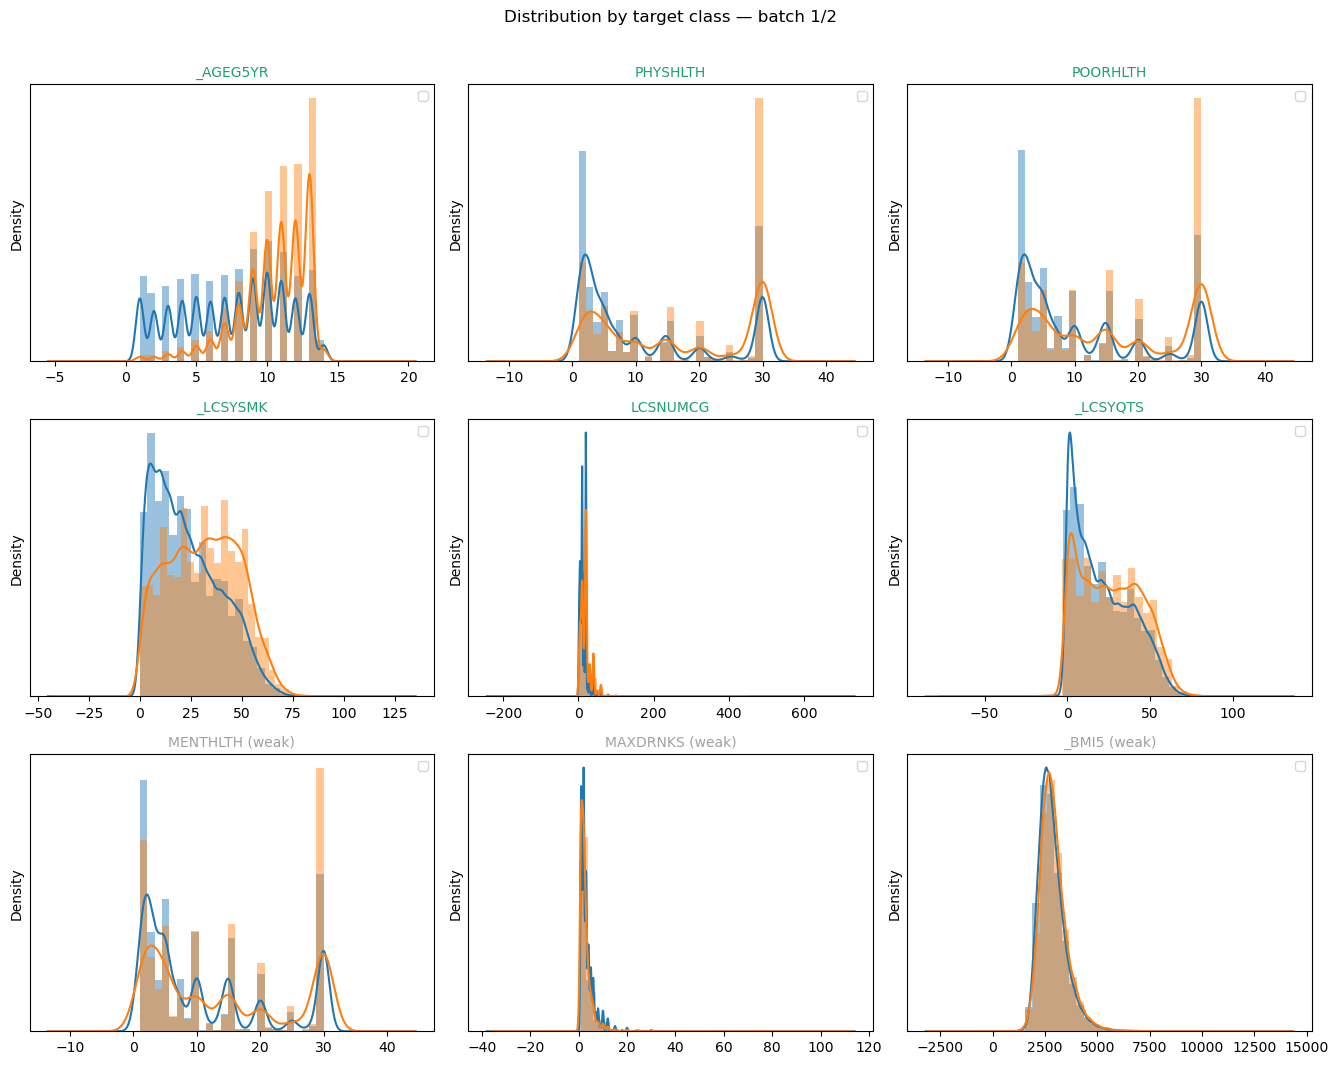

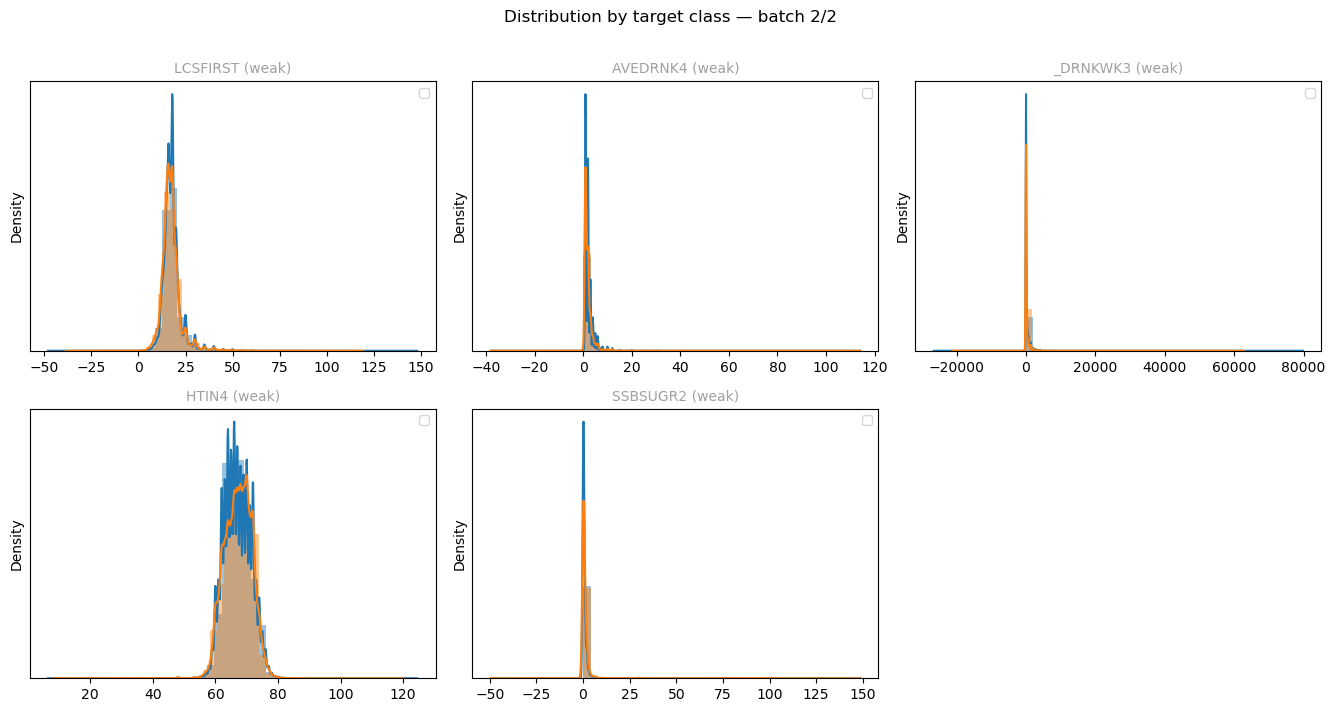

In [ ]:
# Continuous Features

cont_results = []
for col in continuous_cols:
    clean = df[[col, TARGET]].dropna()
    corr, _ = pointbiserialr(clean[col], clean[TARGET])
    g0, g1  = clean[clean[TARGET]==0][col], clean[clean[TARGET]==1][col]
    _, pval = mannwhitneyu(g0, g1, alternative="two-sided")
    cont_results.append({"feature": col, "pb_corr": corr,
                         "abs_corr": abs(corr), "p_mw": pval})

cont_df = pd.DataFrame(cont_results).sort_values("abs_corr", ascending=False)
cont_df["sig_p"]  = cont_df["p_mw"]     < P_THRESHOLD
cont_df["sig_cv"] = cont_df["abs_corr"] > CORR_THRESHOLD

cont_df["sig_cat"] = cont_df.apply(_sig_category, axis=1)

sig_cont = cont_df[cont_df["sig_cat"] == "both"]["feature"].tolist()
all_cont = cont_df["feature"].tolist()

CONT_CAT_LABEL = {
    "both":    f"p < {P_THRESHOLD} & |r| > {CORR_THRESHOLD}",
    "p_only":  f"p < {P_THRESHOLD} only (weak effect)",
    "cv_only": f"|r| > {CORR_THRESHOLD} only (unreliable p)",
    "neither": "Not significant",
}

# ranking chart
feat_idx_c = cont_df.set_index("feature")
plot_df_c  = feat_idx_c.loc[all_cont, "pb_corr"].sort_values()
colors_c   = [CAT_COLOR[feat_idx_c.loc[f, "sig_cat"]] for f in plot_df_c.index]

fig, ax = plt.subplots(figsize=(8, max(3, len(all_cont) * 0.4 + 1)))
plot_df_c.plot(kind="barh", ax=ax, color=colors_c)
ax.axvline(0,                color="black",   linewidth=0.6)
ax.axvline( CORR_THRESHOLD,  color="#F4A736", linewidth=1, linestyle="--")
ax.axvline(-CORR_THRESHOLD,  color="#F4A736", linewidth=1, linestyle="--")
ax.set_xlabel("Point-biserial correlation")
ax.set_title(f"Continuous features - association with {TARGET} "
             f"({len(sig_cont)}/{len(all_cont)} fully significant)")

present_cats_c   = cont_df["sig_cat"].unique()
legend_patches_c = [Patch(color=CAT_COLOR[c], label=CONT_CAT_LABEL[c])
                    for c in ["both", "p_only", "cv_only", "neither"] if c in present_cats_c]
legend_patches_c.append(Line2D([0], [0], color="#F4A736", linewidth=1,
                                linestyle="--", label=f"|r| = {CORR_THRESHOLD}"))
ax.legend(handles=legend_patches_c, loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

# KDE overlay grids
classes    = sorted(df[TARGET].unique())
cmap       = plt.colormaps["tab10"]
kde_colors = [cmap(i) for i in range(len(classes))]

def cont_plot_fn(col, j, ax):
    for k, cls in enumerate(classes):
        subset = df[df[TARGET] == cls][col].dropna()
        if len(subset) < 2:
            continue
        ax.hist(subset, bins=25, alpha=0.45, color=kde_colors[k], density=True,
                label="_nolegend_")
        try:
            subset.plot.kde(ax=ax, color=kde_colors[k], linewidth=1.5,
                            label="_nolegend_")
        except Exception:
            pass

    cat   = feat_idx_c.loc[col, "sig_cat"]
    color = CAT_COLOR[cat] if cat == "both" else "#A0A0A0"
    ax.set_title(f"{col}{CAT_SUFFIX[cat]}", fontsize=10, color=color)
    ax.set_yticks([])

    handles = [Patch(color=kde_colors[k], alpha=0.6, label=f"{TARGET}={cls}")
            for k, cls in enumerate(classes)]
    ax.legend(handles=[h for h in handles if not h.get_label().startswith("_")], fontsize=9)

plot_chunks(all_cont, cont_plot_fn,
            "Distribution by target class - batch {}/{}")

In [13]:
cont_df

,feature,pb_corr,abs_corr,p_mw,sig_p,sig_cv,sig_cat
0,_AGEG5YR,0.228582,0.228582,0.000000e+00,True,True,both
1,PHYSHLTH,0.176781,0.176781,0.000000e+00,True,True,both
3,POORHLTH,0.174363,0.174363,0.000000e+00,True,True,both
6,_LCSYSMK,0.164334,0.164334,0.000000e+00,True,True,both
5,LCSNUMCG,0.126650,0.126650,0.000000e+00,True,True,both
7,_LCSYQTS,0.100238,0.100238,6.320890e-237,True,True,both
2,MENTHLTH,0.086872,0.086872,1.193637e-239,True,False,p_only
10,MAXDRNKS,-0.036866,0.036866,4.475573e-165,True,False,p_only
12,_BMI5,0.036412,0.036412,1.870568e-160,True,False,p_only
4,LCSFIRST,-0.030462,0.030462,1.414677e-64,True,False,p_only


### Summary, Final Selection of Features based on Univariate Significance and Effect Size

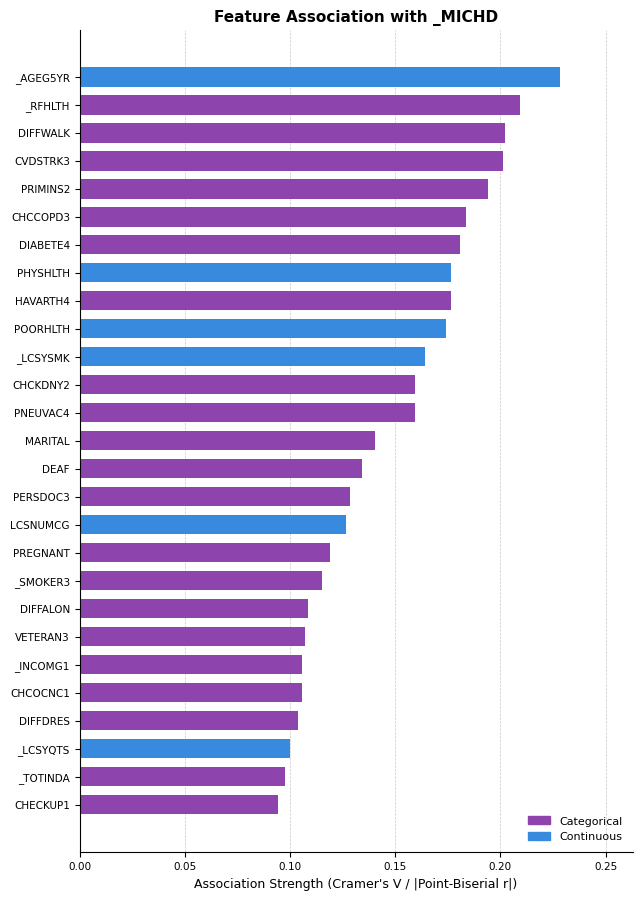

,feature,score,p_val,type
43,CHECKUP1,0.094358,0.000000e+00,categorical
0,_TOTINDA,0.097758,0.000000e+00,categorical
7,_LCSYQTS,0.100238,6.320890e-237,continuous
38,DIFFDRES,0.103791,0.000000e+00,categorical
31,CHCOCNC1,0.105672,0.000000e+00,categorical
6,_INCOMG1,0.105740,0.000000e+00,categorical
3,VETERAN3,0.107073,0.000000e+00,categorical
39,DIFFALON,0.108581,0.000000e+00,categorical
18,_SMOKER3,0.115173,0.000000e+00,categorical
4,PREGNANT,0.118943,0.000000e+00,categorical


In [14]:
# Summary
cat_top = (cat_df[cat_df["sig_cat"].isin(["both"])]
           [["feature", "cramers_v", "p_value"]]
           .rename(columns={"cramers_v": "score", "p_value": "p_val"})
           .assign(type="categorical"))

cont_top = (cont_df[cont_df["sig_cat"].isin(["both"])]
            [["feature", "abs_corr", "p_mw"]]
            .rename(columns={"abs_corr": "score", "p_mw": "p_val"})
            .assign(type="continuous"))

summary = (pd.concat([cat_top, cont_top])
           .sort_values("score", ascending=True))

colors_map = {"categorical": "#8E44AD", "continuous": "#378ADD"}
bar_colors = summary["type"].map(colors_map)

fig, ax = plt.subplots(figsize=(7, len(summary) * 0.35))
bars = ax.barh(summary["feature"], summary["score"], color=bar_colors, height=0.7)

ax.set_xlabel("Association Strength (Cramer's V / |Point-Biserial r|)", fontsize=9)
ax.set_title(f"Feature Association with {TARGET}", fontsize=11, fontweight="bold")
ax.tick_params(axis='y', labelsize=7.5)
ax.tick_params(axis='x', labelsize=7.5)
ax.set_xlim(0, summary["score"].max() * 1.15)
ax.xaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

ax.legend(
    handles=[Patch(color=v, label=k.capitalize()) for k, v in colors_map.items()],
    fontsize=8, frameon=False, loc="lower right"
)

plt.subplots_adjust(left=0.18, right=0.97, top=0.95, bottom=0.08)
plt.show()

summary

### Random Forest Feature Importance. Interaction-Aware Cross-Check
Univariate tests (Cramer’s V, point-biserial r) evaluate each feature in isolation. A feature with a weak *marginal* association can still be important when it **interacts** with other features (e.g., BMI alone is weakly correlated with MI, but BMI × age × diabetes may compound risk). A Random Forest captures these interactions through its tree splits.

Below we fit a quick RF on **all 72 features** (pre-selection) to get an interaction-aware importance ranking, then compare it against the univariate selection to check for missed features.

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.under_sampling import RandomUnderSampler

RANDOM_STATE = 42
ALL_FEATURES = [c for c in df.columns if c != TARGET]

all_cat = [c for c in ALL_FEATURES if c in categorical_cols]
all_cont = [c for c in ALL_FEATURES if c in continuous_cols]

preprocessor_all = ColumnTransformer([
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), all_cat),
    ("cont", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), all_cont),
])

X_all = df[ALL_FEATURES]
y_all = df[TARGET]
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=RANDOM_STATE)

rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_tr_res, y_tr_res = rus.fit_resample(X_tr, y_tr)

rf_all = Pipeline([
    ("preprocessor", preprocessor_all),
    ("model", RandomForestClassifier(
        n_estimators=500, min_samples_leaf=20,
        random_state=RANDOM_STATE, n_jobs=-1)),
])
rf_all.fit(X_tr_res, y_tr_res)

# Map one-hot encoded names back to original features and aggregate
encoded_names = rf_all.named_steps["preprocessor"].get_feature_names_out()
importances = rf_all.named_steps["model"].feature_importances_

imp_raw = pd.DataFrame({"encoded": encoded_names, "importance": importances})

def get_original_feature(name):
    name = name.replace("cat__", "").replace("cont__", "")
    for col in sorted(ALL_FEATURES, key=len, reverse=True):
        if name == col or name.startswith(col + "_"):
            return col
    return name

imp_raw["feature"] = imp_raw["encoded"].apply(get_original_feature)
rf_importance = (imp_raw.groupby("feature")["importance"]
                 .sum().sort_values(ascending=False)
                 .reset_index())
rf_importance.columns = ["feature", "rf_importance"]

print(f"RF trained on {len(ALL_FEATURES)} features")
print(f"\nTop 30 by RF importance:")
print(rf_importance.head(30).to_string(index=False))

RF trained on 72 features

Top 30 by RF importance:
 feature  rf_importance
_AGEG5YR       0.125927
 _RFHLTH       0.102805
HAVARTH4       0.074459
PRIMINS2       0.073145
DIFFWALK       0.054419
CVDSTRK3       0.051503
DIABETE4       0.046400
CHCCOPD3       0.040902
PNEUVAC4       0.040744
PREGNANT       0.040048
 _ismale       0.031650
PERSDOC3       0.030161
_LCSYSMK       0.019160
CHCKDNY2       0.018061
 MARITAL       0.016636
_SMOKER3       0.015591
PHYSHLTH       0.014124
LCSNUMCG       0.013628
    DEAF       0.012734
VETERAN3       0.012169
   _BMI5       0.011402
CHECKUP1       0.010407
   HTIN4       0.010383
CHCOCNC1       0.007791
_LCSYQTS       0.007682
_INCOMG1       0.006208
_TOTINDA       0.006022
 _EDUCAG       0.006011
_DRNKWK3       0.005656
FLUSHOT7       0.005252


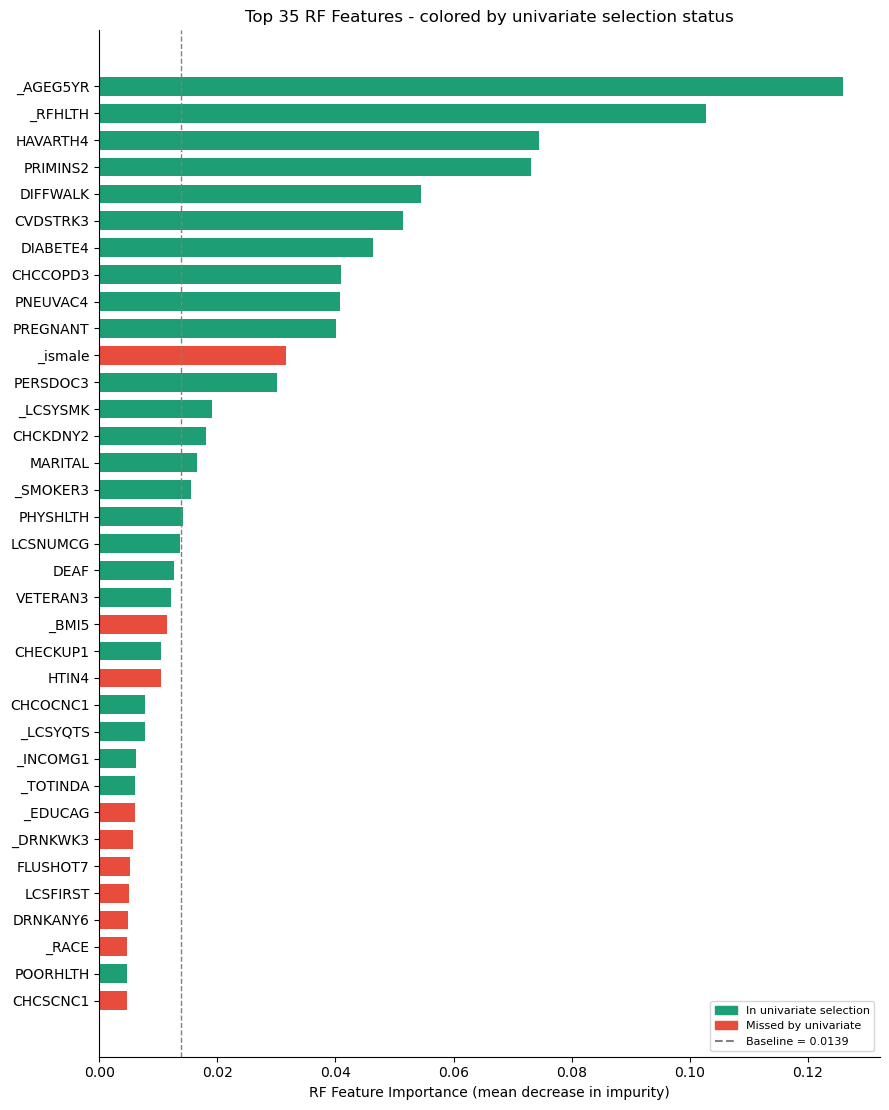


RF above baseline (0.0139): 17 features
Agreed by both methods: 16
Univariate only (RF finds unimportant): 11 → ['CHCOCNC1', 'CHECKUP1', 'DEAF', 'DIFFALON', 'DIFFDRES', 'LCSNUMCG', 'POORHLTH', 'VETERAN3', '_INCOMG1', '_LCSYQTS', '_TOTINDA']
RF only (univariate missed): 1 → ['_ismale']


In [16]:
# Compare univariate selection vs RF importance
univariate_set = set(summary["feature"].tolist())

univ_scores = summary[["feature", "score"]].copy()
comparison = rf_importance.merge(univ_scores, on="feature", how="left")
comparison["in_univariate"] = comparison["feature"].isin(univariate_set)
comparison["score"] = comparison["score"].fillna(0)

baseline = 1.0 / len(ALL_FEATURES)

top_n = 35
plot_data = comparison.head(top_n).copy()
colors_comp = ["#1D9E75" if v else "#E74C3C" for v in plot_data["in_univariate"]]

fig, ax = plt.subplots(figsize=(9, top_n * 0.32))
ax.barh(plot_data["feature"][::-1], plot_data["rf_importance"][::-1],
        color=colors_comp[::-1], height=0.7)
ax.axvline(baseline, color="grey", linestyle="--", lw=1,
           label=f"Baseline (1/{len(ALL_FEATURES)} = {baseline:.4f})")
ax.set_xlabel("RF Feature Importance (mean decrease in impurity)")
ax.set_title(f"Top {top_n} RF Features - colored by univariate selection status")
ax.legend(handles=[
    Patch(color="#1D9E75", label="In univariate selection"),
    Patch(color="#E74C3C", label="Missed by univariate"),
    Line2D([0],[0], color="grey", linestyle="--", label=f"Baseline = {baseline:.4f}"),
], fontsize=8, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

rf_above_baseline = set(comparison[comparison["rf_importance"] > baseline]["feature"])
missed = rf_above_baseline - univariate_set
agreed = rf_above_baseline & univariate_set
univ_only = univariate_set - rf_above_baseline

print(f"\nRF above baseline ({baseline:.4f}): {len(rf_above_baseline)} features")
print(f"Agreed by both methods: {len(agreed)}")
print(f"Univariate only (RF finds unimportant): {len(univ_only)} \u2192 {sorted(univ_only)}")
print(f"RF only (univariate missed): {len(missed)} \u2192 {sorted(missed)}")

In [17]:
# Features found by RF but missed by univariate
missed_df = comparison[comparison["feature"].isin(missed)].copy()

cat_lookup = cat_df.set_index("feature")[["cramers_v", "p_value", "sig_cat"]]
cont_lookup = cont_df.set_index("feature")[["abs_corr", "p_mw", "sig_cat"]].rename(
    columns={"abs_corr": "cramers_v", "p_mw": "p_value"})
univ_lookup = pd.concat([cat_lookup, cont_lookup])

missed_df = missed_df.merge(
    univ_lookup[["cramers_v", "sig_cat"]].reset_index().rename(columns={"index": "feature"}),
    on="feature", how="left")

missed_df = missed_df.sort_values("rf_importance", ascending=False)
print("Features RF found important but univariate rejected:")
print("(sig_cat = p_only means statistically significant but below effect-size threshold)\n")
print(missed_df[["feature", "rf_importance", "cramers_v", "sig_cat"]].to_string(index=False))

Features RF found important but univariate rejected:
(sig_cat = p_only means statistically significant but below effect-size threshold)

feature  rf_importance  cramers_v sig_cat
_ismale        0.03165   0.067341  p_only


### Combined Feature Selection (Univariate ∪ RF)
**Goal: interpretability over model performance.** We include a feature if:
1. It passed univariate selection (strong individual signal), **OR**
2. RF found it important (above the 1/N baseline) AND it has a clear clinical interpretation for MI risk.

We exclude RF-only features that lack clinical relevance or are redundant with existing features (checked via multicollinearity below).

In [18]:
# Merge univariate + RF-surfaced features
combined_set = set(summary["feature"].tolist())
print(f"Univariate base: {len(combined_set)} features")

# Clinical relevance filter for RF-only candidates
CLINICAL_INCLUDE = {
    "ADDEPEV3":  "depression linked to CV outcomes via chronic stress",
    "MENTHLTH":  "mental health days - stress/CV pathway, just missed |r| threshold",
    "_BMI5":     "BMI is a major modifiable MI risk factor",
    "_RFBMI5":   "overweight/obese flag - complements continuous BMI",
    "BLIND":     "vision difficulty - captures disability burden",
    "DECIDE":    "cognitive difficulty - proxies overall health decline",
    "_EDUCAG":   "education level - established social determinant of CV health",
    "_RACE":     "race/ethnicity - captures health disparities in MI outcomes",
    "MEDCOST1":  "cost barrier to care - healthcare access determinant",
    "FLUSHOT7":  "flu shot - proxy for preventive health engagement",
    "_ismale":   "sex - well-established MI risk factor",
}

CLINICAL_EXCLUDE = {
    "_HLTHPL2":  "redundant with PRIMINS2 (already selected)",
    "INSULIN1":  "redundant with DIABETE4 (already selected)",
    "DIABTYPE":  "redundant with DIABETE4 (already selected)",
    "FEETSORE":  "redundant with DIABETE4 (already selected)",
    "_LTASTH1":  "asthma has weak direct link to MI",
    "CHCSCNC1":  "skin cancer - weak MI relevance",
    "HTIN4":     "height - no direct MI mechanism",
    "SSBSUGR2":  "87% missing, weak signal",
    "MSCODE":    "83% missing, not clinically actionable",
}

for feat in sorted(missed):
    rf_imp = rf_importance.set_index("feature").loc[feat, "rf_importance"]
    if feat in CLINICAL_INCLUDE:
        print(f"  + ADD   {feat:12s} (RF={rf_imp:.4f}) - {CLINICAL_INCLUDE[feat]}")
        combined_set.add(feat)
    elif feat in CLINICAL_EXCLUDE:
        print(f"  - skip  {feat:12s} (RF={rf_imp:.4f}) - {CLINICAL_EXCLUDE[feat]}")
    else:
        print(f"  - skip  {feat:12s} (RF={rf_imp:.4f}) - no clear clinical MI pathway")

n_added = len(combined_set) - len(summary["feature"].tolist())
print(f"\nFinal combined selection: {len(combined_set)} features (+{n_added} from RF)")


Univariate base: 27 features
  + ADD   _ismale      (RF=0.0316) - sex - well-established MI risk factor

Final combined selection: 28 features (+1 from RF)


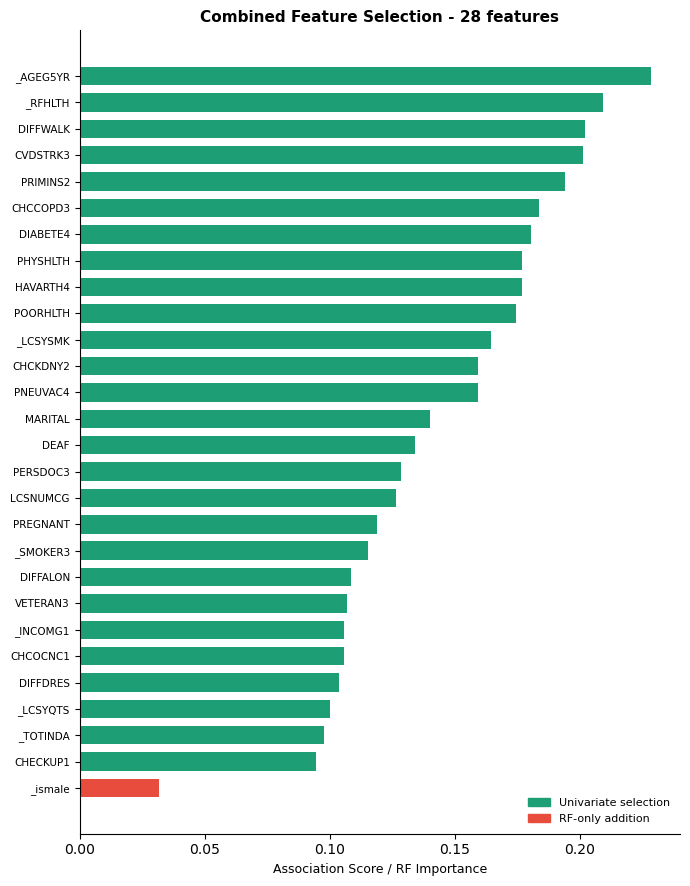

 feature    score        type     source
 _ismale 0.031650 categorical    rf_only
CHECKUP1 0.094358 categorical univariate
_TOTINDA 0.097758 categorical univariate
_LCSYQTS 0.100238  continuous univariate
DIFFDRES 0.103791 categorical univariate
CHCOCNC1 0.105672 categorical univariate
_INCOMG1 0.105740 categorical univariate
VETERAN3 0.107073 categorical univariate
DIFFALON 0.108581 categorical univariate
_SMOKER3 0.115173 categorical univariate
PREGNANT 0.118943 categorical univariate
LCSNUMCG 0.126650  continuous univariate
PERSDOC3 0.128626 categorical univariate
    DEAF 0.134053 categorical univariate
 MARITAL 0.140185 categorical univariate
PNEUVAC4 0.159317 categorical univariate
CHCKDNY2 0.159443 categorical univariate
_LCSYSMK 0.164334  continuous univariate
POORHLTH 0.174363  continuous univariate
HAVARTH4 0.176755 categorical univariate
PHYSHLTH 0.176781  continuous univariate
DIABETE4 0.180588 categorical univariate
CHCCOPD3 0.183726 categorical univariate
PRIMINS2 0.19392

In [19]:
# Rebuild summary table with combined features
rf_additions = combined_set - set(summary["feature"].tolist())

rf_rows = []
for feat in rf_additions:
    rf_imp = rf_importance.set_index("feature").loc[feat, "rf_importance"]
    feat_type = "categorical" if feat in categorical_cols else "continuous"
    rf_rows.append({"feature": feat, "score": rf_imp, "p_val": np.nan,
                    "type": feat_type, "source": "rf_only"})

summary_combined = summary.copy()
summary_combined["source"] = "univariate"
summary_combined = pd.concat([summary_combined, pd.DataFrame(rf_rows)], ignore_index=True)
summary_combined = summary_combined.sort_values("score", ascending=True)

# Plot
source_colors = {"univariate": "#1D9E75", "rf_only": "#E74C3C"}
bar_colors = summary_combined["source"].map(source_colors)

fig, ax = plt.subplots(figsize=(7, len(summary_combined) * 0.32))
ax.barh(summary_combined["feature"], summary_combined["score"],
        color=bar_colors, height=0.7)
ax.set_xlabel("Association Score / RF Importance", fontsize=9)
ax.set_title(f"Combined Feature Selection - {len(summary_combined)} features",
             fontsize=11, fontweight="bold")
ax.tick_params(axis="y", labelsize=7.5)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(handles=[
    Patch(color="#1D9E75", label="Univariate selection"),
    Patch(color="#E74C3C", label="RF-only addition"),
], fontsize=8, frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

# Replace summary for downstream use (multicollinearity check + pickle)
summary = summary_combined
print(summary[["feature", "score", "type", "source"]].to_string(index=False))


### Correlation Matrix on the Final Column List to Spot Multicollinearity

High-correlation pairs (>0.7):


,feature_a,feature_b,metric,value,p_value


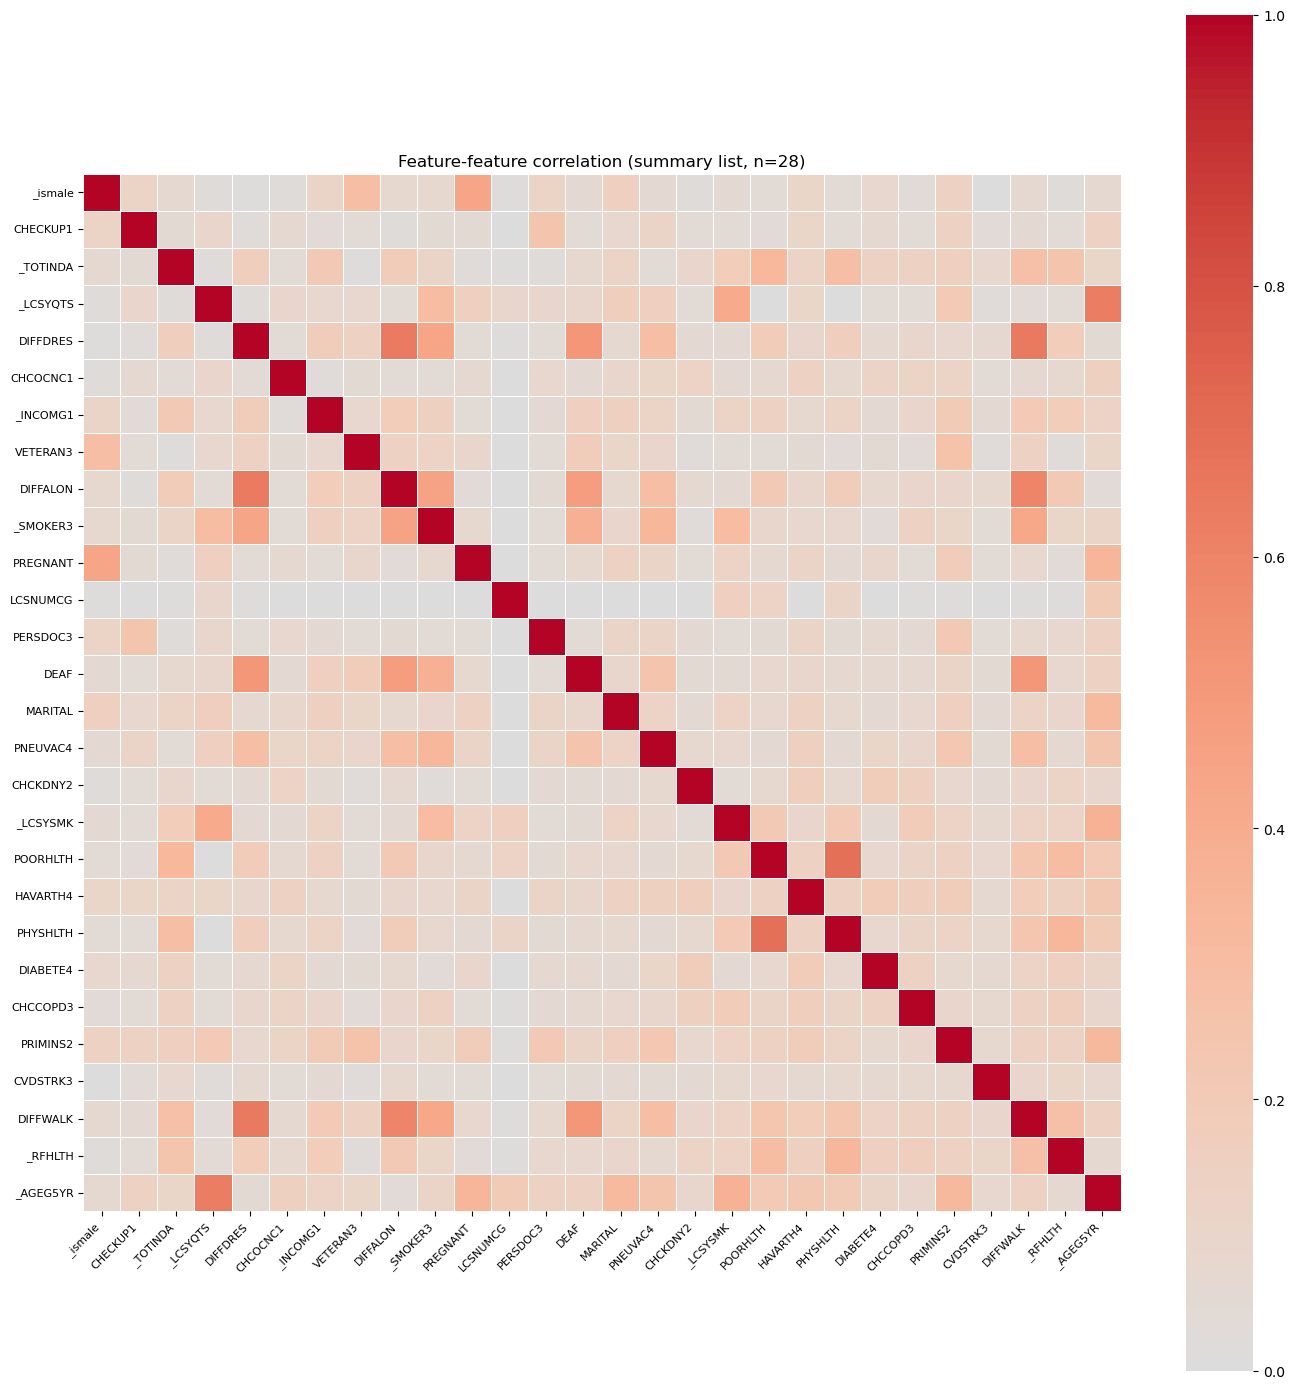

In [20]:
summary_features = summary["feature"].tolist()
summary_cat  = [f for f in summary_features if f in categorical_cols]
summary_cont = [f for f in summary_features if f in continuous_cols]

# categorical-categorical: Cramer's V
cat_corr_results = []
for i, a in enumerate(summary_cat):
    for b in summary_cat[i+1:]:
        clean = df[[a, b]].dropna()
        ct    = pd.crosstab(clean[a], clean[b])
        cv    = cramers_v(clean[a], clean[b])
        _, pval, _, _ = chi2_contingency(ct)
        cat_corr_results.append({"feature_a": a, "feature_b": b,
                                  "metric": "cramers_v", "value": cv, "p_value": pval})

# continuous-continuous: Pearson r
cont_corr_results = []
for i, a in enumerate(summary_cont):
    for b in summary_cont[i+1:]:
        clean = df[[a, b]].dropna()
        r, pval = pearsonr(clean[a], clean[b])
        cont_corr_results.append({"feature_a": a, "feature_b": b,
                                   "metric": "pearson_r", "value": abs(r), "p_value": pval})

# categorical-continuous: Cramer's V
mixed_corr_results = []
for a in summary_cat:
    for b in summary_cont:
        clean = df[[a, b]].dropna()
        clean[b] = pd.cut(clean[b], bins=5).astype(str)  # bin continuous into ordinal categories
        ct = pd.crosstab(clean[a], clean[b])
        cv = cramers_v(clean[a], clean[b])
        _, pval, _, _ = chi2_contingency(ct)
        mixed_corr_results.append({"feature_a": a, "feature_b": b,
                                    "metric": "cramers_v", "value": cv, "p_value": pval})

pair_df = (pd.concat([pd.DataFrame(r) for r in
                      [cat_corr_results, cont_corr_results, mixed_corr_results]
                      if r])
           .sort_values("value", ascending=False)
           .reset_index(drop=True))

PAIR_THRESHOLD = 0.7
pair_df["high_corr"] = pair_df["value"] > PAIR_THRESHOLD

print(f"High-correlation pairs (>{PAIR_THRESHOLD}):")
display(pair_df[pair_df["high_corr"]][["feature_a", "feature_b", "metric", "value", "p_value"]])

corr_matrix = pd.DataFrame(index=summary_features, columns=summary_features, dtype=float)
np.fill_diagonal(corr_matrix.values, 1.0)

for _, row in pair_df.iterrows():
    corr_matrix.loc[row["feature_a"], row["feature_b"]] = row["value"]
    corr_matrix.loc[row["feature_b"], row["feature_a"]] = row["value"]

corr_matrix = corr_matrix.fillna(0)

fig, ax = plt.subplots(figsize=(max(8, len(summary_features) * 0.5),
                                max(6, len(summary_features) * 0.5)))
sns.heatmap(corr_matrix.astype(float), ax=ax, cmap="coolwarm", center=0,
            vmin=0, vmax=1, annot=len(summary_features) <= 20,
            fmt=".2f", linewidths=0.5, square=True,
            xticklabels=True, yticklabels=True)
ax.set_title(f"Feature-feature correlation (summary list, n={len(summary_features)})")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout(); plt.show()

### No significant multicollinearity detected in the final selection of features\. Below is the final selection\.

In [21]:
selected_features = summary['feature']
selected_features

27     _ismale
0     CHECKUP1
1     _TOTINDA
2     _LCSYQTS
3     DIFFDRES
4     CHCOCNC1
5     _INCOMG1
6     VETERAN3
7     DIFFALON
8     _SMOKER3
9     PREGNANT
10    LCSNUMCG
11    PERSDOC3
12        DEAF
13     MARITAL
14    PNEUVAC4
15    CHCKDNY2
16    _LCSYSMK
17    POORHLTH
18    HAVARTH4
19    PHYSHLTH
20    DIABETE4
21    CHCCOPD3
22    PRIMINS2
23    CVDSTRK3
24    DIFFWALK
25     _RFHLTH
26    _AGEG5YR
Name: feature, dtype: object

In [22]:
with open(os.path.join(DATA_DIR, "selected_features.pkl"), "wb") as f:
    pickle.dump(selected_features, f)

# Quick Random Forest to Evaluate if it Works

In [23]:
# imports
from sklearn.ensemble         import RandomForestClassifier
from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics          import (classification_report, confusion_matrix,
                                      roc_auc_score, roc_curve,
                                      precision_recall_curve, average_precision_score)
from sklearn.preprocessing    import StandardScaler, OneHotEncoder
from sklearn.impute            import SimpleImputer
from sklearn.pipeline          import Pipeline
from sklearn.compose           import ColumnTransformer
from imblearn.under_sampling   import RandomUnderSampler
import matplotlib.gridspec as gridspec

Before resampling - 0: 328,101 | 1: 33,870
After resampling - 0: 33,870 | 1: 33,870
Test (untouched) - 0: 82,025 | 1: 8,468

CV AUC (5-fold): 0.8386 ± 0.0040

Test AUC: 0.8398
Test Avg Precision: 0.3602

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.72      0.83     82025
         1.0       0.23      0.81      0.36      8468

    accuracy                           0.72     90493
   macro avg       0.60      0.76      0.59     90493
weighted avg       0.90      0.72      0.78     90493



C:\Users\18327\AppData\Local\Temp\ipykernel_26532\1604689672.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


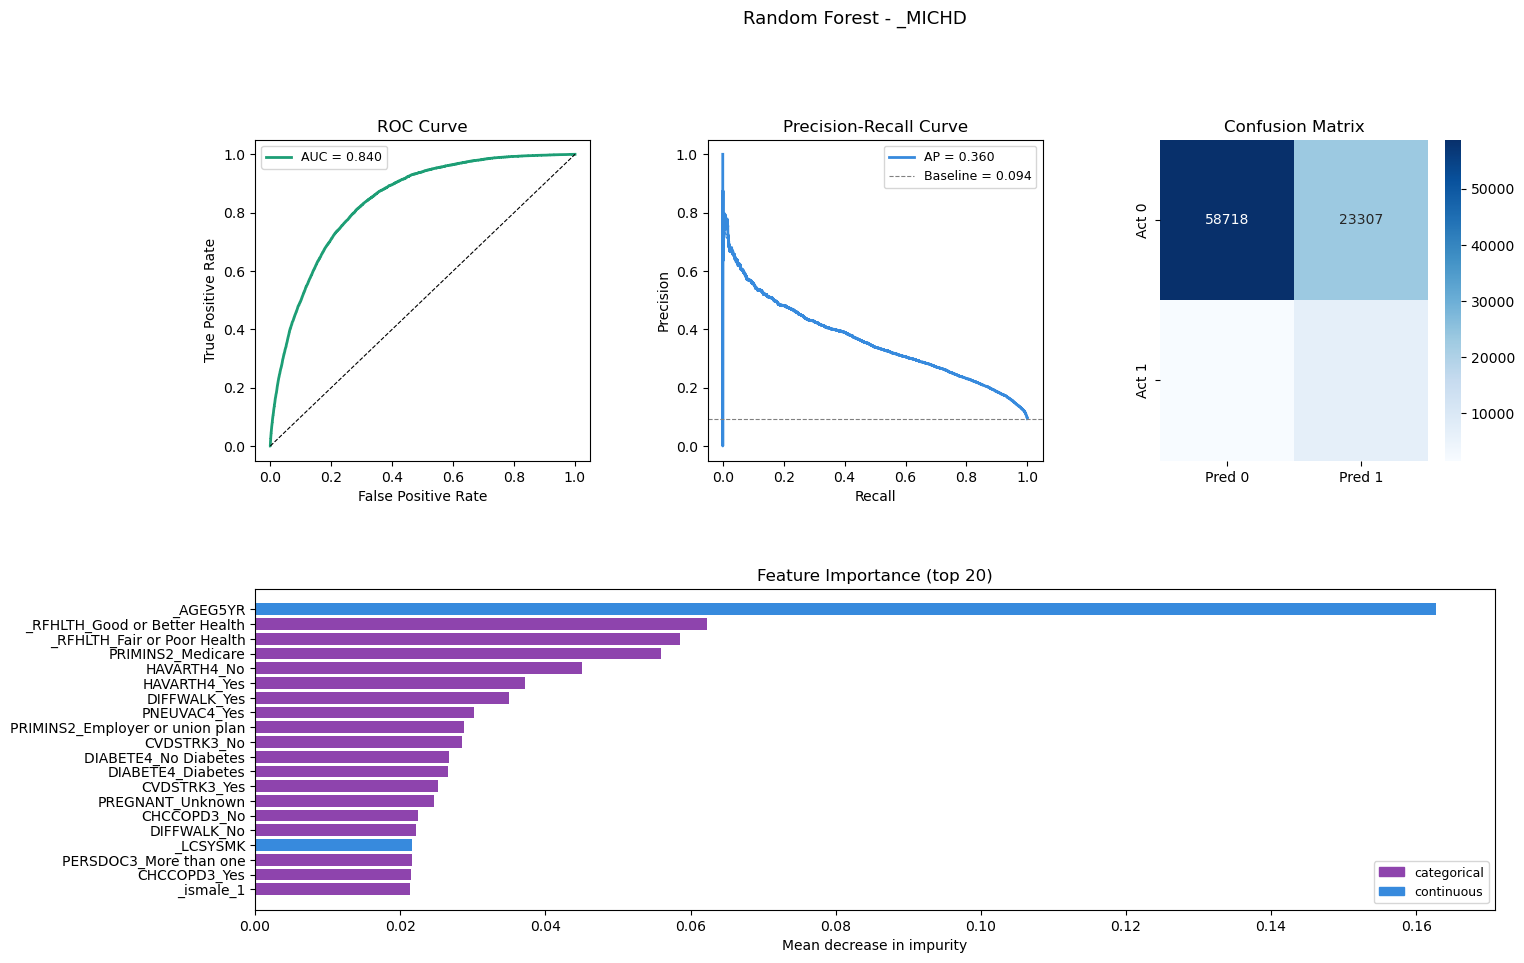

In [24]:
# config
FEATURES = summary["feature"].tolist()
TEST_SIZE = 0.2
RANDOM_STATE = 42
CV_FOLDS = 5
RF_PARAMS = {
    "n_estimators": 1000,
    "max_depth": None,
    "min_samples_leaf": 20,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

df = df[df[TARGET].notna()]

# data prep
model_df = df[FEATURES + [TARGET]].copy()
X = model_df[FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

# undersample majority class on train only
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

print(f"Before resampling - 0: {(y_train==0).sum():,} | 1: {(y_train==1).sum():,}")
print(f"After resampling - 0: {(y_train_res==0).sum():,} | 1: {(y_train_res==1).sum():,}")
print(f"Test (untouched) - 0: {(y_test==0).sum():,} | 1: {(y_test==1).sum():,}")

# Preprocessing pipeline
cat_features = [f for f in FEATURES if f in categorical_cols]
cont_features = [f for f in FEATURES if f in continuous_cols]

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

cont_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer([
    ("categorical", cat_transformer, cat_features),
    ("continuous", cont_transformer, cont_features),
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(**RF_PARAMS)),
])

# fit
pipeline.fit(X_train_res, y_train_res)

# cross-validated AUC (on resampled train)
cv_auc = cross_val_score(pipeline, X_train_res, y_train_res, cv=StratifiedKFold(CV_FOLDS, shuffle=True, random_state=RANDOM_STATE), scoring="roc_auc", n_jobs=-1)
print(f"\nCV AUC ({CV_FOLDS}-fold): {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

# test set evaluation
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_prob)
test_ap = average_precision_score(y_test, y_prob)

print(f"\nTest AUC: {test_auc:.4f}")
print(f"Test Avg Precision: {test_ap:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

# Extract transformed feature names
transformed_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

def get_feature_type(name):
    if name.startswith("categorical__"): return "categorical"
    return "continuous"

# plots
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ROC curve
ax1 = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax1.plot(fpr, tpr, color="#1D9E75", lw=2, label=f"AUC = {test_auc:.3f}")
ax1.plot([0,1], [0,1], "k--", lw=0.8)
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve"); ax1.legend(fontsize=9)

# Precision-Recall curve
ax2 = fig.add_subplot(gs[0, 1])
prec, rec, _ = precision_recall_curve(y_test, y_prob)
ax2.plot(rec, prec, color="#378ADD", lw=2, label=f"AP = {test_ap:.3f}")
ax2.axhline(y_test.mean(), color="grey", linestyle="--", lw=0.8, label=f"Baseline = {y_test.mean():.3f}")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve"); ax2.legend(fontsize=9)

# Confusion matrix
ax3 = fig.add_subplot(gs[0, 2])
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax3, xticklabels=[f"Pred {c}" for c in [0,1]], yticklabels=[f"Act {c}" for c in [0,1]])
ax3.set_title("Confusion Matrix")

# Feature importance (top 20)
ax4 = fig.add_subplot(gs[1, :])
rf_model = pipeline.named_steps["model"]

imp_df = pd.DataFrame({
    "feature": transformed_names,
    "importance": rf_model.feature_importances_
})
imp_df["type"] = imp_df["feature"].apply(get_feature_type)
imp_df["feature"] = imp_df["feature"].str.replace(r"^(categorical__|continuous__)", "", regex=True)

imp_df = imp_df.sort_values("importance", ascending=False).head(20)

colors_map = {
    "categorical": "#8E44AD",
    "continuous": "#378ADD"
}
imp_colors = imp_df["type"].map(colors_map).tolist()

ax4.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color=imp_colors[::-1])
ax4.set_xlabel("Mean decrease in impurity")
ax4.set_title("Feature Importance (top 20)")
ax4.legend(handles=[Patch(color=v, label=k) for k, v in colors_map.items()], fontsize=9)

plt.suptitle(f"Random Forest - {TARGET}", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=88479c56-07bc-4e04-92b4-d8345dc226f4' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>